# 01 — Exploratory Data Analysis

Credit Scoring Dataset

The goals are:

- Understand the structure and quality of the data  
- Inspect the target distribution  
- Identify missing values  
- Explore feature distributions  
- Detect correlations and potential issues  
- Produce insights that will guide preprocessing and modeling decisions

Dataset: [*Default of Credit Card Clients* (UCI)](https://www.kaggle.com/datasets/uciml/default-of-credit-card-clients-dataset/data)

## Imports

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")


## Load Data

In [23]:
df = pd.read_csv("../data/raw/UCI_Credit_Card.csv")
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,-2,-2,3913.0,3102.0,689.0,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,0,2,2682.0,1725.0,2682.0,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,0,0,29239.0,14027.0,13559.0,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,0,0,46990.0,48233.0,49291.0,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,0,0,8617.0,5670.0,35835.0,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


## Basic Overview

In [24]:
df.info()
df.describe().T

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       30000 non-null  int64  
 7   PAY_2                       30000 non-null  int64  
 8   PAY_3                       30000 non-null  int64  
 9   PAY_4                       30000 non-null  int64  
 10  PAY_5                       30000 non-null  int64  
 11  PAY_6                       30000 non-null  int64  
 12  BILL_AMT1                   30000 non-null  float64
 13  BILL_AMT2                   30000 non-null

,count,mean,std,min,25%,50%,75%,max
ID,30000.0,15000.500000,8660.398374,1.0,7500.75,15000.5,22500.25,30000.0
LIMIT_BAL,30000.0,167484.322667,129747.661567,10000.0,50000.00,140000.0,240000.00,1000000.0
SEX,30000.0,1.603733,0.489129,1.0,1.00,2.0,2.00,2.0
EDUCATION,30000.0,1.853133,0.790349,0.0,1.00,2.0,2.00,6.0
MARRIAGE,30000.0,1.551867,0.521970,0.0,1.00,2.0,2.00,3.0
AGE,30000.0,35.485500,9.217904,21.0,28.00,34.0,41.00,79.0
PAY_0,30000.0,-0.016700,1.123802,-2.0,-1.00,0.0,0.00,8.0
PAY_2,30000.0,-0.133767,1.197186,-2.0,-1.00,0.0,0.00,8.0
PAY_3,30000.0,-0.166200,1.196868,-2.0,-1.00,0.0,0.00,8.0
PAY_4,30000.0,-0.220667,1.169139,-2.0,-1.00,0.0,0.00,8.0


## Target Analysis

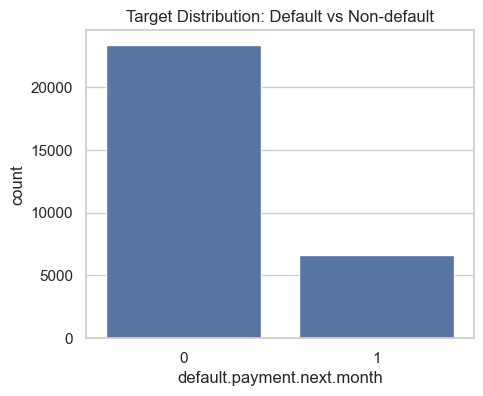

In [25]:
df["default.payment.next.month"].value_counts(normalize=True)

plt.figure(figsize=(5,4))
sns.countplot(x="default.payment.next.month", data=df)
plt.title("Target Distribution: Default vs Non-default")
plt.show()

## Missing Values

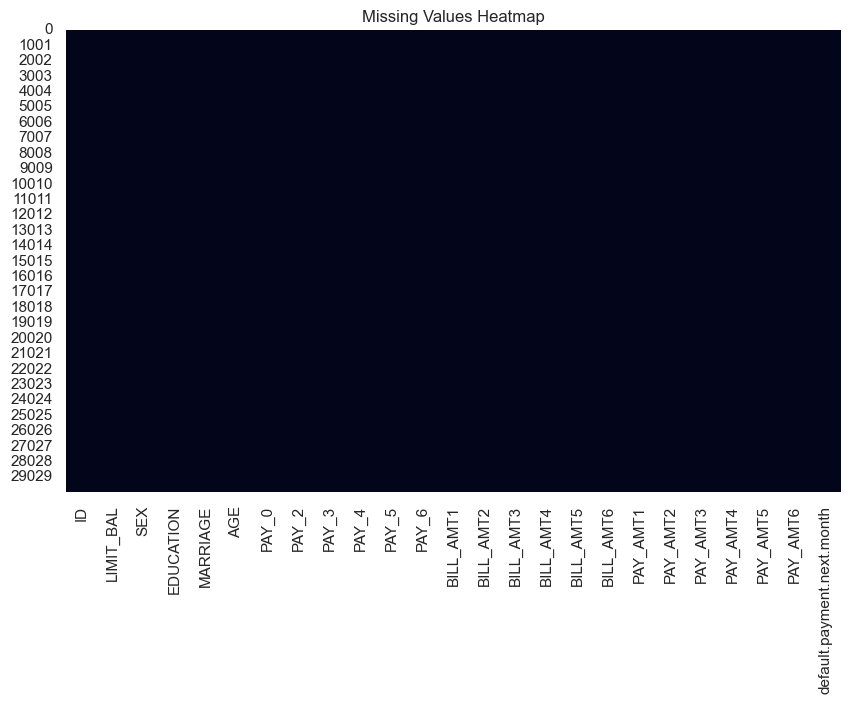

In [26]:
df.isna().sum().sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.heatmap(df.isna(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()

## Numerical Feature Distributions

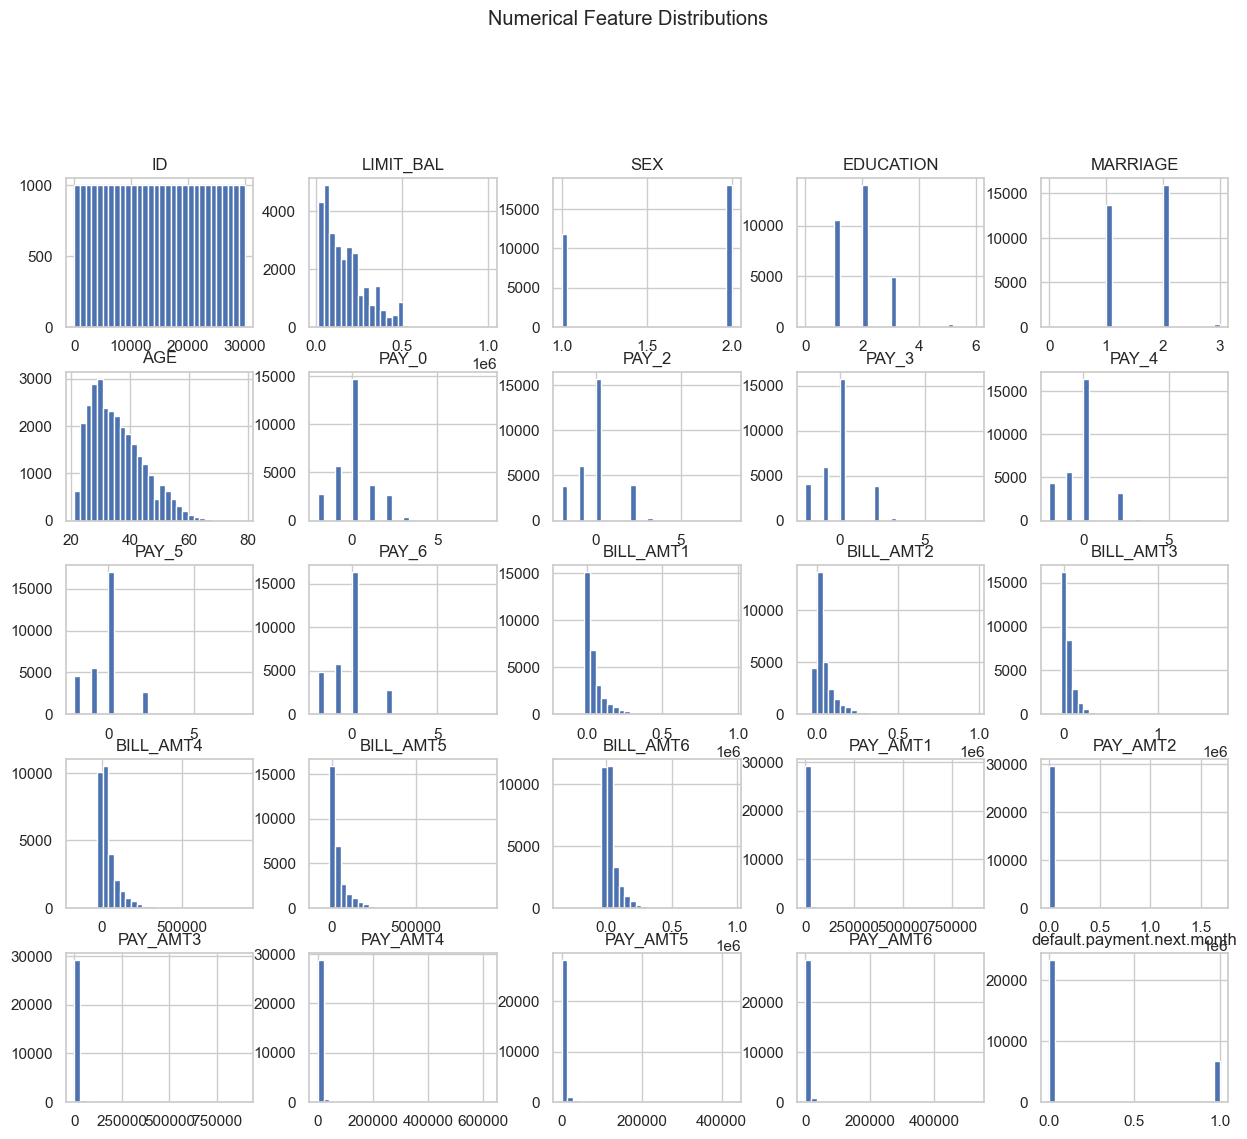

In [27]:
num_cols = df.select_dtypes(include=[np.number]).columns

df[num_cols].hist(figsize=(15,12), bins=30)
plt.suptitle("Numerical Feature Distributions", y=1.02)
plt.show()

## Correlation Matrix

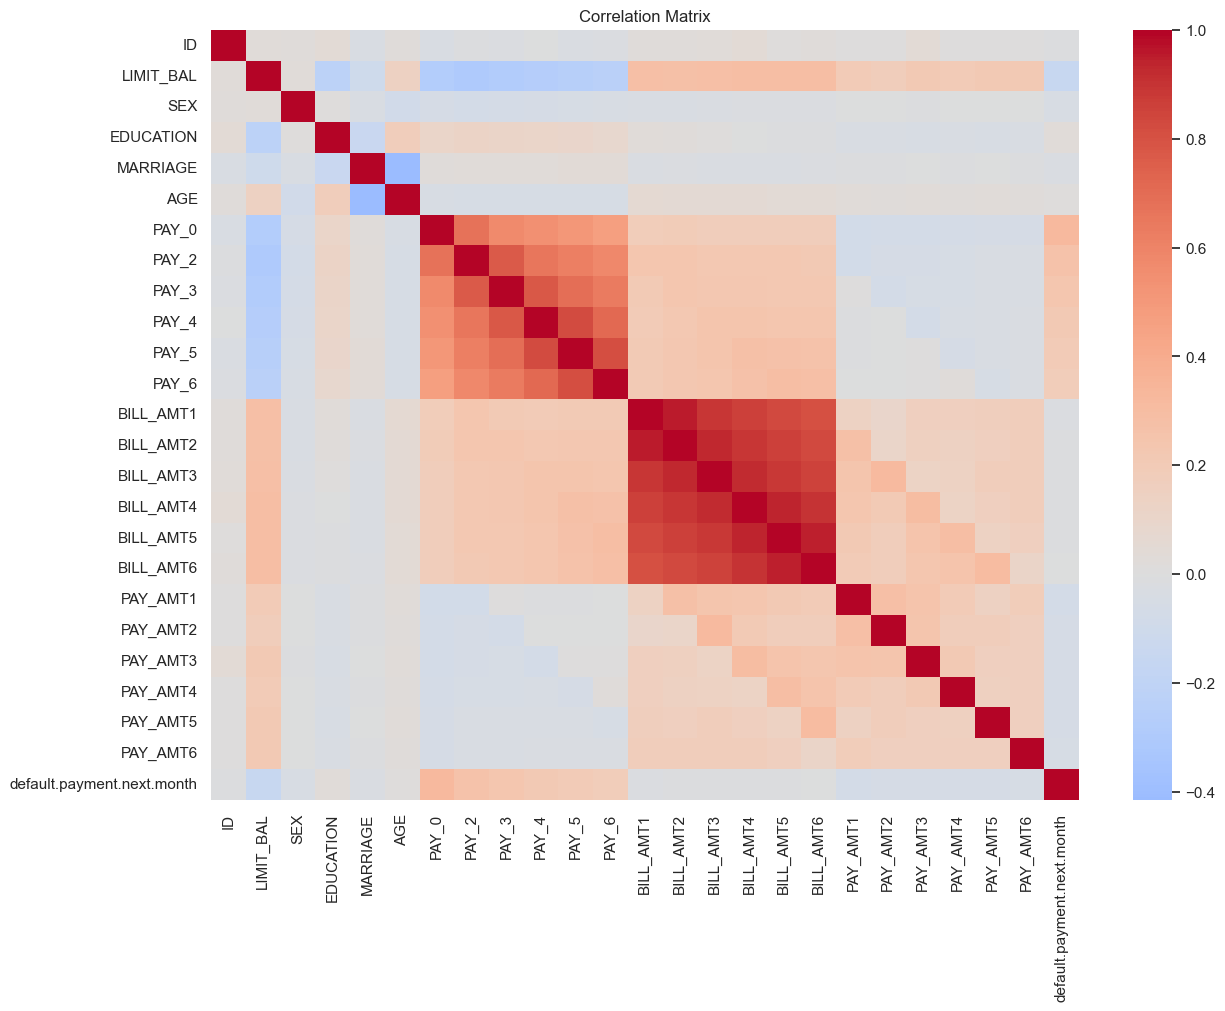

In [28]:
plt.figure(figsize=(14,10))
sns.heatmap(df.corr(), cmap="coolwarm", center=0)
plt.title("Correlation Matrix")
plt.show()

## Quick Summary

- Dataset has 30,000 rows and 25 columns.
- Target `default.payment.next.month` is imbalanced: about 78% class 0 and 22% class 1.
- I did not find missing values (`isna()` gives 0).
- Most columns are numeric, so no one-hot encoding is needed right now.
- `PAY_0`, `PAY_2`, `PAY_3`, `PAY_4`, `PAY_5` look most related to target in correlation heatmap.

### What to do next

- Use stratified train/test split.
- Try Logistic Regression first (with class_weight), then tree models.
- Check ROC-AUC and recall, not only accuracy.